In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.prepared import prep
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from IPython.display import display

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linestyle'] = ':'

# =====================================================================
# CONFIGURACION GENERAL
# =====================================================================
START_DATE = '1979-01-01'
END_DATE = '2021-12-31'
DRY_THRESHOLD = 1.0          # mm/dia
EVENT_THRESHOLD = 20         # dias
BOOTSTRAP_ITER = 300
RANDOM_SEED = 42
PERIOD_1 = (1979, 2000)
PERIOD_2 = (2001, 2021)
THRESHOLD_SWEEP = [5, 10, 15, 20, 25, 30, 35, 40]

# =====================================================================
# FUNCIONES AUXILIARES
# =====================================================================
def load_araucania_polygon():
    shp = shpreader.natural_earth(
        resolution='10m',
        category='cultural',
        name='admin_1_states_provinces',
    )
    reader = shpreader.Reader(shp)
    for rec in reader.records():
        attrs = rec.attributes
        if attrs.get('admin') == 'Chile' and attrs.get('name_alt') == 'IX':
            return rec.geometry, attrs.get('name')
    raise ValueError('No se encontro la Region de La Araucania en Natural Earth.')


def build_region_mask(lat2d, lon2d, polygon):
    polygon_prepared = prep(polygon)
    mask = np.zeros(lat2d.shape, dtype=bool)
    for j in range(lat2d.shape[0]):
        for i in range(lat2d.shape[1]):
            mask[j, i] = polygon_prepared.contains(Point(float(lon2d[j, i]), float(lat2d[j, i])))
    return mask


def extract_dry_spells(pr_values, times, threshold):
    records = []
    nlat, nlon = pr_values.shape[1], pr_values.shape[2]

    for j in range(nlat):
        for i in range(nlon):
            vals = pr_values[:, j, i]
            if np.all(np.isnan(vals)):
                continue

            is_dry = np.isfinite(vals) & (vals < threshold)
            x = np.concatenate(([0], is_dry.astype(np.int8), [0]))
            dx = np.diff(x)
            starts = np.where(dx == 1)[0]
            ends = np.where(dx == -1)[0]

            for s, e in zip(starts, ends):
                duration = int(e - s)
                if duration <= 0:
                    continue
                start_date = pd.Timestamp(times[s])
                records.append({
                    'start_year': int(start_date.year),
                    'duration': duration,
                })

    return pd.DataFrame(records)


def event_probability(spell_df, start_year, end_year, min_duration):
    subset = spell_df[(spell_df['start_year'] >= start_year) & (spell_df['start_year'] <= end_year)].copy()
    total_spells = int(len(subset))
    event_spells = int((subset['duration'] >= min_duration).sum())
    probability = event_spells / total_spells
    return subset, probability, event_spells, total_spells


def risk_ratio(prob_period_2, prob_period_1):
    return prob_period_2 / prob_period_1


def bootstrap_rr_by_year(spell_df, years_1, years_2, min_duration, n_iter=BOOTSTRAP_ITER, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    grouped = {year: spell_df.loc[spell_df['start_year'] == year, 'duration'].to_numpy() for year in sorted(spell_df['start_year'].unique())}
    years_1 = np.array(list(years_1))
    years_2 = np.array(list(years_2))
    rr_values = []

    for _ in range(n_iter):
        draw_1 = rng.choice(years_1, size=len(years_1), replace=True)
        draw_2 = rng.choice(years_2, size=len(years_2), replace=True)

        sample_1 = np.concatenate([grouped[year] for year in draw_1 if grouped[year].size > 0])
        sample_2 = np.concatenate([grouped[year] for year in draw_2 if grouped[year].size > 0])

        if sample_1.size == 0 or sample_2.size == 0:
            continue

        p1 = np.mean(sample_1 >= min_duration)
        p2 = np.mean(sample_2 >= min_duration)
        if p1 > 0:
            rr_values.append(p2 / p1)

    return np.array(rr_values)


def summarize_period(label, start_year, end_year, probability, event_spells, total_spells):
    return {
        'Periodo': label,
        'Anios': f'{start_year}-{end_year}',
        'Dry spells totales': total_spells,
        f'Dry spells >= {EVENT_THRESHOLD} dias': event_spells,
        'Probabilidad del evento': probability,
    }


print('1/4: Cargando CR2MET y construyendo mascara de La Araucania...')
polygon, region_name = load_araucania_polygon()
minx, miny, maxx, maxy = polygon.bounds

ds = xr.open_mfdataset('./pr/CR2MET_pr_v2.5_day_*.nc', chunks={'time': 365})
ds = ds.sel(
    time=slice(START_DATE, END_DATE),
    lat=slice(miny - 0.2, maxy + 0.2),
    lon=slice(minx - 0.2, maxx + 0.2),
)

lat2d, lon2d = np.meshgrid(ds['lat'].values, ds['lon'].values, indexing='ij')
region_mask = build_region_mask(lat2d, lon2d, polygon)
mask_da = xr.DataArray(region_mask, coords={'lat': ds['lat'], 'lon': ds['lon']}, dims=('lat', 'lon'))

pr_region = ds['pr'].where(mask_da)
region_pixels = int(region_mask.sum())

print(f'Region seleccionada: {region_name}')
print(f'Periodo analizado: {START_DATE} a {END_DATE}')
print(f'Pixeles CR2MET dentro de la region: {region_pixels}')
print(f'Umbral de dia seco: pr < {DRY_THRESHOLD:.1f} mm/dia')


1/4: Cargando CR2MET y construyendo mascara de La Araucania...
Region seleccionada: La Araucanía
Periodo analizado: 1979-01-01 a 2021-12-31
Pixeles CR2MET dentro de la region: 1401
Umbral de dia seco: pr < 1.0 mm/dia


2/4: Extrayendo dry spells de toda la region...
Total de dry spells en La Araucania: 2,809,335


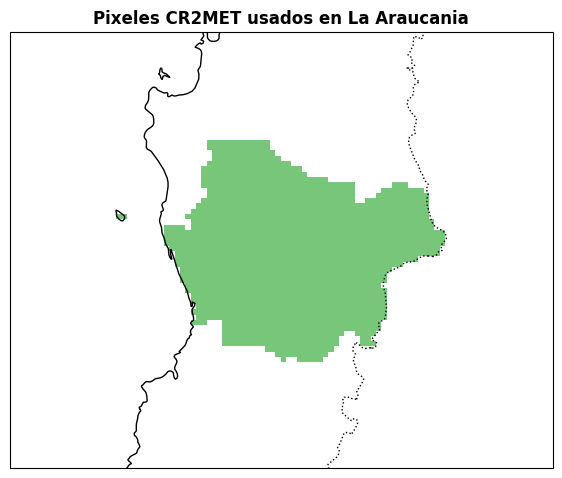

In [2]:
# =====================================================================
# EXTRACCION DE DRY SPELLS Y MAPA DE LA REGION
# =====================================================================
print('2/4: Extrayendo dry spells de toda la region...')

pr_region_c = pr_region.compute()
spell_df = extract_dry_spells(pr_region_c.values, pd.to_datetime(pr_region_c['time'].values), DRY_THRESHOLD)

print(f'Total de dry spells en La Araucania: {len(spell_df):,}')

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([minx - 1.0, maxx + 1.0, miny - 1.0, maxy + 1.0])

region_plot = xr.DataArray(mask_da.astype(float), coords=mask_da.coords, dims=mask_da.dims)
region_plot = region_plot.where(region_plot > 0)
region_plot.plot.pcolormesh(ax=ax, x='lon', y='lat', transform=ccrs.PlateCarree(), cmap='YlGn', add_colorbar=False)
ax.set_title('Pixeles CR2MET usados en La Araucania', fontweight='bold')
plt.show()


3/4: Calculando risk ratio para dry spells de al menos 20 dias...


,Periodo,Anios,Dry spells totales,Dry spells >= 20 dias,Probabilidad del evento (%)
0,Historico de referencia,1979-2000,1417527,34021,2.400
1,Periodo reciente,2001-2021,1391808,31792,2.284


,Evento,RR observado (2001-2021 / 1979-2000),RR bootstrap mediano,IC95 RR bootstrap - limite inferior,IC95 RR bootstrap - limite superior
0,Dry spell >= 20 dias,0.952,0.942,0.71,1.28


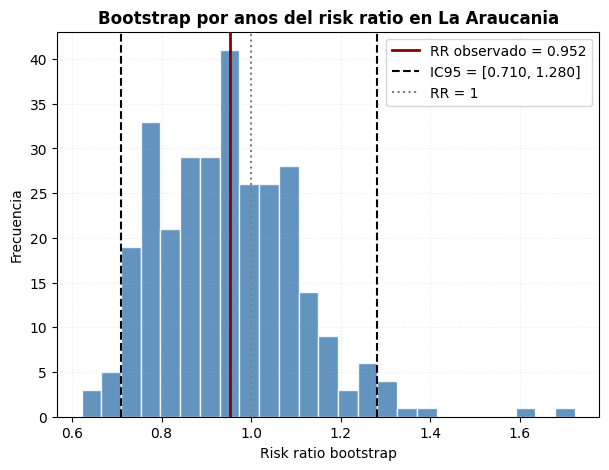

Definicion usada:
  RR = P(D >= 20 dias en 2001-2021) / P(D >= 20 dias en 1979-2000)
  donde D es la duracion de cada dry spell.


In [3]:
# =====================================================================
# RISK RATIO PRINCIPAL PARA EL EVENTO D >= 20 DIAS
# =====================================================================
print('3/4: Calculando risk ratio para dry spells de al menos 20 dias...')

years_1 = range(PERIOD_1[0], PERIOD_1[1] + 1)
years_2 = range(PERIOD_2[0], PERIOD_2[1] + 1)

period_1_df, prob_1, hits_1, total_1 = event_probability(spell_df, PERIOD_1[0], PERIOD_1[1], EVENT_THRESHOLD)
period_2_df, prob_2, hits_2, total_2 = event_probability(spell_df, PERIOD_2[0], PERIOD_2[1], EVENT_THRESHOLD)
rr_20 = risk_ratio(prob_2, prob_1)

rr_boot = bootstrap_rr_by_year(spell_df, years_1, years_2, EVENT_THRESHOLD)
rr_ci_low, rr_ci_med, rr_ci_high = np.percentile(rr_boot, [2.5, 50, 97.5])

summary_table = pd.DataFrame([
    summarize_period('Historico de referencia', PERIOD_1[0], PERIOD_1[1], prob_1, hits_1, total_1),
    summarize_period('Periodo reciente', PERIOD_2[0], PERIOD_2[1], prob_2, hits_2, total_2),
])
summary_table['Probabilidad del evento (%)'] = summary_table['Probabilidad del evento'] * 100.0
summary_table = summary_table.drop(columns=['Probabilidad del evento'])
display(summary_table.round(3))

rr_table = pd.DataFrame([{
    'Evento': f'Dry spell >= {EVENT_THRESHOLD} dias',
    'RR observado (2001-2021 / 1979-2000)': rr_20,
    'RR bootstrap mediano': rr_ci_med,
    'IC95 RR bootstrap - limite inferior': rr_ci_low,
    'IC95 RR bootstrap - limite superior': rr_ci_high,
}])
display(rr_table.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(rr_boot, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(rr_20, color='darkred', linewidth=2, label=f'RR observado = {rr_20:.3f}')
ax.axvline(rr_ci_low, color='black', linestyle='--', linewidth=1.5, label=f'IC95 = [{rr_ci_low:.3f}, {rr_ci_high:.3f}]')
ax.axvline(rr_ci_high, color='black', linestyle='--', linewidth=1.5)
ax.axvline(1.0, color='gray', linestyle=':', linewidth=1.5, label='RR = 1')
ax.set_xlabel('Risk ratio bootstrap')
ax.set_ylabel('Frecuencia')
ax.set_title('Bootstrap por anos del risk ratio en La Araucania', fontweight='bold')
ax.legend()
plt.show()

print('Definicion usada:')
print('  RR = P(D >= 20 dias en 2001-2021) / P(D >= 20 dias en 1979-2000)')
print('  donde D es la duracion de cada dry spell.')


4/4: Explorando como cambia el risk ratio con el umbral de duracion...


,Umbral de duracion (dias),Probabilidad 1979-2000 (%),Probabilidad 2001-2021 (%),RR (2001-2021 / 1979-2000),Eventos 1979-2000,Eventos 2001-2021
0,5,34.075,34.586,1.015,483021,481371
1,10,12.054,11.593,0.962,170871,161348
2,15,5.197,4.946,0.952,73670,68839
3,20,2.400,2.284,0.952,34021,31792
4,25,1.354,1.478,1.092,19190,20572
5,30,1.039,0.997,0.960,14723,13877
6,35,0.717,0.676,0.943,10167,9413
7,40,0.482,0.503,1.043,6833,6997


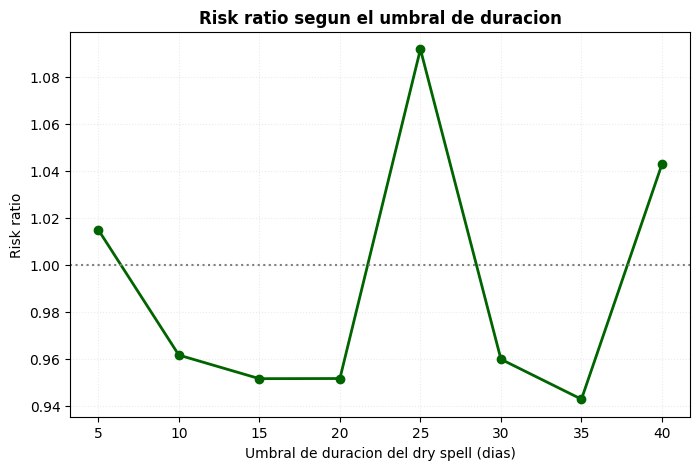

Lectura de este grafico:
  - RR > 1 indica que el evento es mas probable en 2001-2021 que en 1979-2000.
  - RR < 1 indica que el evento es menos probable en 2001-2021 que en 1979-2000.
  - RR = 1 indica que la probabilidad no cambia entre periodos.


In [4]:
# =====================================================================
# RISK RATIO COMO FUNCION DEL UMBRAL DE DURACION
# =====================================================================
print('4/4: Explorando como cambia el risk ratio con el umbral de duracion...')

threshold_rows = []
for threshold in THRESHOLD_SWEEP:
    _, p1, h1, n1 = event_probability(spell_df, PERIOD_1[0], PERIOD_1[1], threshold)
    _, p2, h2, n2 = event_probability(spell_df, PERIOD_2[0], PERIOD_2[1], threshold)
    threshold_rows.append({
        'Umbral de duracion (dias)': threshold,
        'Probabilidad 1979-2000 (%)': p1 * 100.0,
        'Probabilidad 2001-2021 (%)': p2 * 100.0,
        'RR (2001-2021 / 1979-2000)': p2 / p1,
        'Eventos 1979-2000': h1,
        'Eventos 2001-2021': h2,
    })

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    threshold_table['Umbral de duracion (dias)'],
    threshold_table['RR (2001-2021 / 1979-2000)'],
    color='darkgreen',
    marker='o',
    linewidth=2,
)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.5)
ax.set_xlabel('Umbral de duracion del dry spell (dias)')
ax.set_ylabel('Risk ratio')
ax.set_title('Risk ratio segun el umbral de duracion', fontweight='bold')
plt.show()

print('Lectura de este grafico:')
print('  - RR > 1 indica que el evento es mas probable en 2001-2021 que en 1979-2000.')
print('  - RR < 1 indica que el evento es menos probable en 2001-2021 que en 1979-2000.')
print('  - RR = 1 indica que la probabilidad no cambia entre periodos.')
